In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

In [2]:
df = pd.read_csv("online_retail_II.csv", encoding="latin1")

In [3]:
print(f"✅ Dataset loaded: {len(df)} rows, {len(df.columns)} columns")
print(f"📋 Columns: {list(df.columns)}")
df.head()

✅ Dataset loaded: 1067371 rows, 8 columns
📋 Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())
print(f"\nTotal rows before cleaning: {len(df)}")

Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Total rows before cleaning: 1067371


In [5]:
# Remove rows with missing Customer ID and Description
# dropna(subset=[...]) → sadece bu sütunlarda boş olanları sil
df = df.dropna(subset=["Customer ID", "Description"])

# Remove cancelled orders
# Invoice'u string'e çevir, C ile başlayanları çıkar
# str.startswith("C") → "C" ile başlayan invoice = iptal edilmiş sipariş
df = df[~df["Invoice"].astype(str).str.startswith("C")]

# Remove negative quantities and prices
# Negatif quantity → iade, negatif price → hatalı veri
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]

# Calculate total amount per row
# Her satır için toplam tutar = fiyat x adet
df["TotalAmount"] = df["Quantity"] * df["Price"]

# Convert Customer ID to integer
df["Customer ID"] = df["Customer ID"].astype(int)

print(f"✅ Rows after cleaning: {len(df)}")
print(f"👥 Unique customers: {df['Customer ID'].nunique()}")
print(f"🌍 Countries: {df['Country'].nunique()}")
df.head()

✅ Rows after cleaning: 805549
👥 Unique customers: 5878
🌍 Countries: 41


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [7]:
# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Now calculate reference date
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"📅 Reference date: {reference_date}")

📅 Reference date: 2011-12-10 12:50:00


In [8]:
# Calculate RFM metrics for each customer
rfm = df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("TotalAmount", "sum")
).reset_index()

print(f"✅ RFM calculated for {len(rfm)} customers")
rfm.head(10)

✅ RFM calculated for 5878 customers


,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,5633.32
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40
5,12351,375,1,300.93
6,12352,36,10,2849.84
7,12353,204,2,406.76
8,12354,232,1,1079.40
9,12355,214,2,947.61


In [9]:
# Score each customer from 1 to 5
# pd.qcut → divides data into equal groups (quartiles)
# Recency: lower is better (recent customers get higher score)
# so we reverse the labels [5,4,3,2,1]
rfm["R_Score"] = pd.qcut(rfm["Recency"], q=5, labels=[5,4,3,2,1])

# Frequency: higher is better
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=5, labels=[1,2,3,4,5])

# Monetary: higher is better
rfm["M_Score"] = pd.qcut(rfm["Monetary"], q=5, labels=[1,2,3,4,5])

# Combine scores into one RFM score
rfm["RFM_Score"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)

print("✅ RFM Scores calculated!")
rfm.head(10)

✅ RFM Scores calculated!


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,12,77556.46,2,5,5,255
1,12347,2,8,5633.32,5,4,5,545
2,12348,75,5,2019.40,3,4,4,344
3,12349,19,4,4428.69,5,3,5,535
4,12350,310,1,334.40,2,1,2,212
5,12351,375,1,300.93,2,1,2,212
6,12352,36,10,2849.84,4,5,4,454
7,12353,204,2,406.76,2,2,2,222
8,12354,232,1,1079.40,2,1,3,213
9,12355,214,2,947.61,2,2,3,223


In [10]:
# Define customer segments based on RFM Score
def segment_customer(row):
    r = int(row["R_Score"])
    f = int(row["F_Score"])
    m = int(row["M_Score"])
    
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"          # best customers
    elif r >= 3 and f >= 3:
        return "Loyal Customers"    # buy regularly
    elif r >= 4 and f <= 2:
        return "New Customers"      # bought recently but not often
    elif r <= 2 and f >= 3:
        return "At Risk"            # used to buy, haven't come back
    elif r <= 2 and f <= 2 and m <= 2:
        return "Lost"               # haven't bought in a long time
    else:
        return "Potential"          # in between

# apply() → her satır için fonksiyonu çalıştır
rfm["Segment"] = rfm.apply(segment_customer, axis=1)

print("✅ Segments assigned!")
print(rfm["Segment"].value_counts())

✅ Segments assigned!
Segment
Loyal Customers    1403
Champions          1300
Lost               1275
At Risk             824
Potential           633
New Customers       443
Name: count, dtype: int64


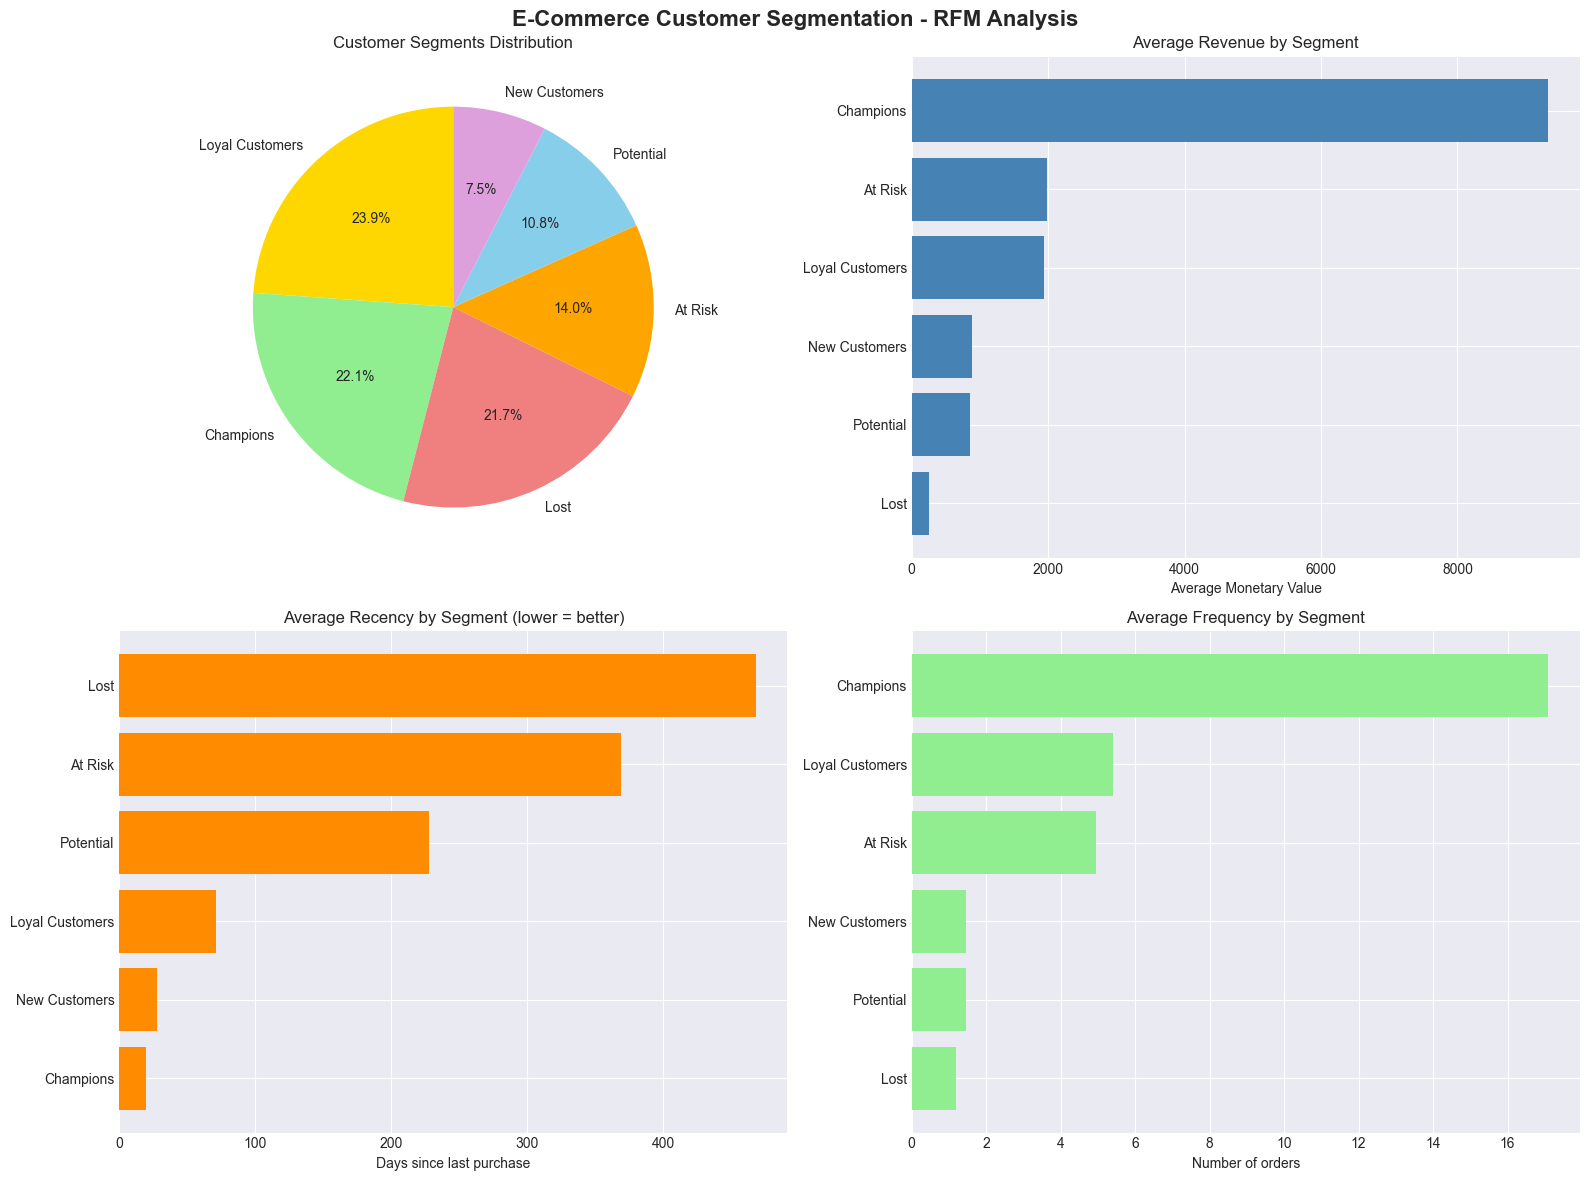

✅ Chart saved!


In [11]:
plt.style.use("seaborn-v0_8-darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("E-Commerce Customer Segmentation - RFM Analysis", 
             fontsize=16, fontweight="bold")

# --- Chart 1: Customer segments pie chart ---
segment_counts = rfm["Segment"].value_counts()
colors = ["gold", "lightgreen", "lightcoral", "orange", "skyblue", "plum"]
axes[0,0].pie(segment_counts.values, labels=segment_counts.index, 
              colors=colors, autopct="%1.1f%%", startangle=90)
axes[0,0].set_title("Customer Segments Distribution")

# --- Chart 2: Average Monetary by segment ---
avg_monetary = rfm.groupby("Segment")["Monetary"].mean().sort_values()
axes[0,1].barh(avg_monetary.index, avg_monetary.values, color="steelblue")
axes[0,1].set_title("Average Revenue by Segment")
axes[0,1].set_xlabel("Average Monetary Value")

# --- Chart 3: Average Recency by segment ---
avg_recency = rfm.groupby("Segment")["Recency"].mean().sort_values()
axes[1,0].barh(avg_recency.index, avg_recency.values, color="darkorange")
axes[1,0].set_title("Average Recency by Segment (lower = better)")
axes[1,0].set_xlabel("Days since last purchase")

# --- Chart 4: Average Frequency by segment ---
avg_frequency = rfm.groupby("Segment")["Frequency"].mean().sort_values()
axes[1,1].barh(avg_frequency.index, avg_frequency.values, color="lightgreen")
axes[1,1].set_title("Average Frequency by Segment")
axes[1,1].set_xlabel("Number of orders")

plt.tight_layout()
plt.savefig("rfm_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved!")